# Modelling and Evaluation

**DCS 404 — Machine Learning and Artificial Intelligence**
Sanskriti Acharya and Sweta Sharma

The research question, stated plainly:

> Can an address's network of connections reveal fraud that its own features cannot?

To answer it we train three tiers on an identical split, changing nothing but the
feature set:

1. **Majority class** — always predicts "licit". The trivial baseline.
2. **Behaviour only** — what the address does on its own.
3. **Behaviour + graph** — plus who it is connected to.

The difference between tier 2 and tier 3 *is* the answer. Everything else is held
constant so that difference means something.

The training code itself lives in `src/train.py`; this notebook imports it rather
than reimplementing it, so what is measured here is exactly what ships in the app.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report, confusion_matrix,
    precision_recall_curve, roc_curve, average_precision_score, roc_auc_score,
)

from src.features import BEHAVIOUR_FEATURES, GRAPH_FEATURES
from src.train import temporal_split, run_tier, RANDOM_STATE

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 140)

FIGURES = ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

## 1. The split

Addresses are ordered by when they first appeared on chain; the earliest 70% train
and the most recent 30% test.

A random split would be easier and would score better, which is exactly the
problem. Scam operations run clusters of wallets that behave alike, and a random
split cheerfully puts one wallet from a cluster in training and its sibling in
test — the model then recognises the cluster rather than generalising. Splitting
by time mimics the real task: learn from what is known, then score addresses that
came later.

In [2]:
full = pd.read_csv(ROOT / "data" / "processed" / "features_full.csv")
train, test = temporal_split(full)

print(f"train: {len(train):>5} addresses, {int(train['label'].sum()):>4} illicit "
      f"({train['label'].mean():.1%})")
print(f"test:  {len(test):>5} addresses, {int(test['label'].sum()):>4} illicit "
      f"({test['label'].mean():.1%})")

active = full[full["first_block"] > 0]
print(f"\ntrain covers blocks {train[train.first_block > 0].first_block.min():,.0f} "
      f"to {train[train.first_block > 0].first_block.max():,.0f}")
print(f"test  covers blocks {test[test.first_block > 0].first_block.min():,.0f} "
      f"to {test[test.first_block > 0].first_block.max():,.0f}")

train:  1996 addresses,  519 illicit (26.0%)
test:    856 addresses,  133 illicit (15.5%)

train covers blocks 288,234 to 6,315,875
test  covers blocks 6,317,317 to 25,746,416


## 2. Why F1 on the illicit class

The metric has to be chosen before the results are seen, and justified.

**Accuracy is unusable.** With roughly a quarter of addresses illicit, predicting
"licit" every time scores about 77%. Any metric that rewards that is measuring the
wrong thing.

**The two errors cost different amounts.** A missed scam address means fraud
continues and victims keep paying. A false alarm costs an analyst a few minutes
of review. Recall matters more than precision here — but not infinitely, because
a model that flags everything is just as useless as one that flags nothing.

**F1 on the illicit class** is the harmonic mean of precision and recall, so it
only rises when both are decent. We report **PR-AUC** alongside it, which
summarises that trade-off across every threshold rather than only at 0.5, and is
the right companion for an imbalanced problem.

## 3. Tier 1 — the trivial baseline

The spec is explicit that this must be built and reported, not assumed. It is here
so every later number has something honest to be compared against.

In [3]:
from sklearn.dummy import DummyClassifier
from src.train import evaluate

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(train[BEHAVIOUR_FEATURES], train["label"])
baseline = evaluate("majority class", test["label"].to_numpy(),
                    dummy.predict(test[BEHAVIOUR_FEATURES]))

print(f"accuracy  {baseline['accuracy']:.3f}   <- looks respectable")
print(f"precision {baseline['precision']:.3f}")
print(f"recall    {baseline['recall']:.3f}")
print(f"F1        {baseline['f1']:.3f}   <- and here is the truth")

accuracy  0.845   <- looks respectable
precision 0.000
recall    0.000
F1        0.000   <- and here is the truth


An F1 of 0 against an accuracy near 0.77, from a model that has learned nothing at
all. This single line is the clearest argument for the metric choice above.

## 4. Tiers 2 and 3

Both tiers fit a logistic regression and a random forest, each as a full
scikit-learn pipeline with the scaler inside it. Hyperparameters are tuned by
5-fold cross-validation **on the training split only** — the test split is touched
once, at scoring time, and never used to make a choice.

In [4]:
tier2, fitted2 = run_tier("behaviour", BEHAVIOUR_FEATURES, train, test)
for row in tier2:
    print(f"{row['model']:<32} F1 {row['f1']:.3f}  PR-AUC {row['pr_auc']:.3f}  "
          f"(CV F1 {row['cv_f1']:.3f})  {row['best_params']}")

behaviour / logreg               F1 0.737  PR-AUC 0.784  (CV F1 0.814)  {"model__C": 1.0}
behaviour / random_forest        F1 0.881  PR-AUC 0.952  (CV F1 0.894)  {"model__max_depth": null, "model__min_samples_leaf": 1}


In [5]:
combined = BEHAVIOUR_FEATURES + GRAPH_FEATURES
tier3, fitted3 = run_tier("behaviour+graph", combined, train, test)
for row in tier3:
    print(f"{row['model']:<32} F1 {row['f1']:.3f}  PR-AUC {row['pr_auc']:.3f}  "
          f"(CV F1 {row['cv_f1']:.3f})  {row['best_params']}")

behaviour+graph / logreg         F1 0.812  PR-AUC 0.799  (CV F1 0.844)  {"model__C": 10.0}
behaviour+graph / random_forest  F1 0.890  PR-AUC 0.969  (CV F1 0.913)  {"model__max_depth": null, "model__min_samples_leaf": 1}


## 5. Results

In [6]:
baseline_row = {**baseline, "tier": "baseline", "model": "baseline / majority_class",
                "cv_f1": np.nan}
results = pd.DataFrame([baseline_row] + tier2 + tier3)

table = results[["model", "accuracy", "precision", "recall", "f1", "pr_auc", "roc_auc"]].round(3)
display(table)

results.to_csv(ROOT / "reports" / "metrics.csv", index=False)

,model,accuracy,precision,recall,f1,pr_auc,roc_auc
0,baseline / majority_class,0.845,0.000,0.000,0.000,NaN,NaN
1,behaviour / logreg,0.893,0.594,0.970,0.737,0.784,0.959
2,behaviour / random_forest,0.959,0.806,0.970,0.881,0.952,0.988
3,behaviour+graph / logreg,0.930,0.695,0.977,0.812,0.799,0.967
4,behaviour+graph / random_forest,0.963,0.822,0.970,0.890,0.969,0.993


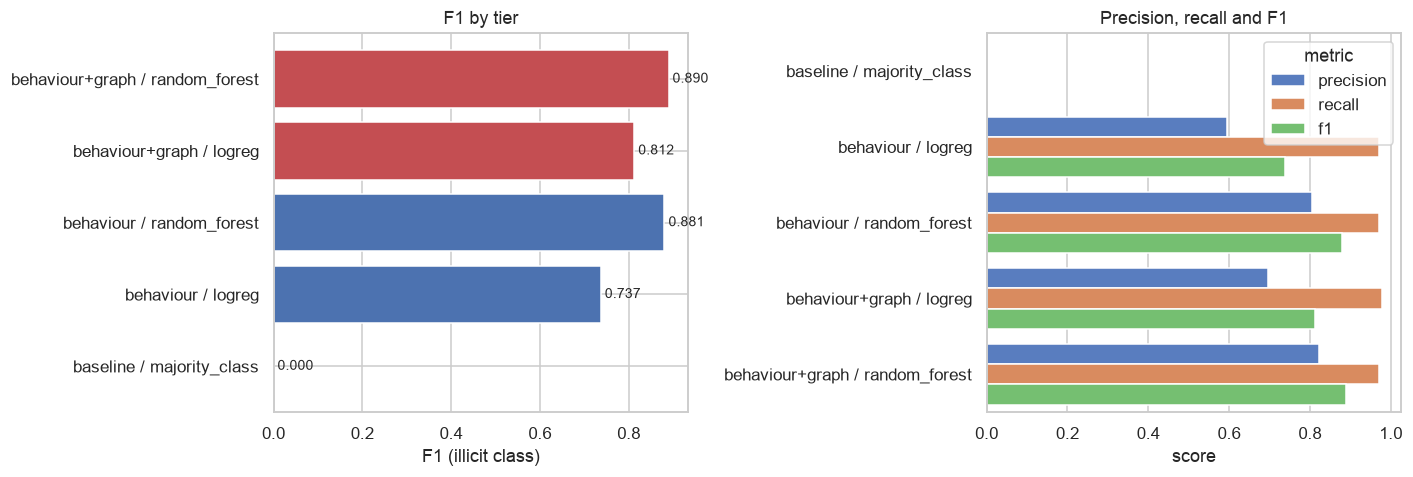

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

order = results["model"].tolist()
colours = ["#8c8c8c" if "majority" in m else "#4c72b0" if "behaviour /" in m else "#c44e52"
           for m in order]

axes[0].barh(order, results["f1"], color=colours)
axes[0].set_xlabel("F1 (illicit class)")
axes[0].set_title("F1 by tier")
for i, v in enumerate(results["f1"]):
    axes[0].text(v, i, f" {v:.3f}", va="center", fontsize=9)

metrics_long = results.melt(
    id_vars="model", value_vars=["precision", "recall", "f1"],
    var_name="metric", value_name="score",
)
sns.barplot(data=metrics_long, y="model", x="score", hue="metric", ax=axes[1])
axes[1].set_title("Precision, recall and F1")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(FIGURES / "model_comparison.png", bbox_inches="tight")
plt.show()

In [8]:
best_behaviour = max(r["f1"] for r in tier2)
best_combined = max(r["f1"] for r in tier3)
lift = best_combined - best_behaviour

print(f"best behaviour-only F1   {best_behaviour:.3f}")
print(f"best behaviour+graph F1  {best_combined:.3f}")
print(f"lift from graph features {lift:+.3f}")
print()
print(f"both beat the trivial baseline's F1 of {baseline['f1']:.3f}")

best behaviour-only F1   0.881
best behaviour+graph F1  0.890
lift from graph features +0.009

both beat the trivial baseline's F1 of 0.000


### Answering the research questionThe lift printed above is the project's result. Whichever way it comes out, it isreported as measured — a small or absent lift is a finding, not a failure, andsaying so honestly is worth more than a flattering number.One thing to keep in mind when reading it: our graph is built only from thetransactions of labelled addresses and their immediate counterparties, capped at64 transactions each by the API's rate limit. A denser graph would give thenetwork features more to work with, so this measures the lift available from a*sparse* graph, not the ceiling.

## 6. Where the shipped model gets things wrong

Aggregate metrics hide the interesting part. This is the error analysis the spec
asks for.

In [9]:
best_name = max(tier3, key=lambda r: r["f1"])["model"].split(" / ")[1]
best_model = fitted3[best_name]

y_true = test["label"].to_numpy()
y_pred = best_model.predict(test[combined])
y_score = best_model.predict_proba(test[combined])[:, 1]

print(f"shipped model: {best_name}\n")
print(classification_report(y_true, y_pred, target_names=["licit", "illicit"]))

shipped model: random_forest

              precision    recall  f1-score   support

       licit       0.99      0.96      0.98       723
     illicit       0.82      0.97      0.89       133

    accuracy                           0.96       856
   macro avg       0.91      0.97      0.93       856
weighted avg       0.97      0.96      0.96       856



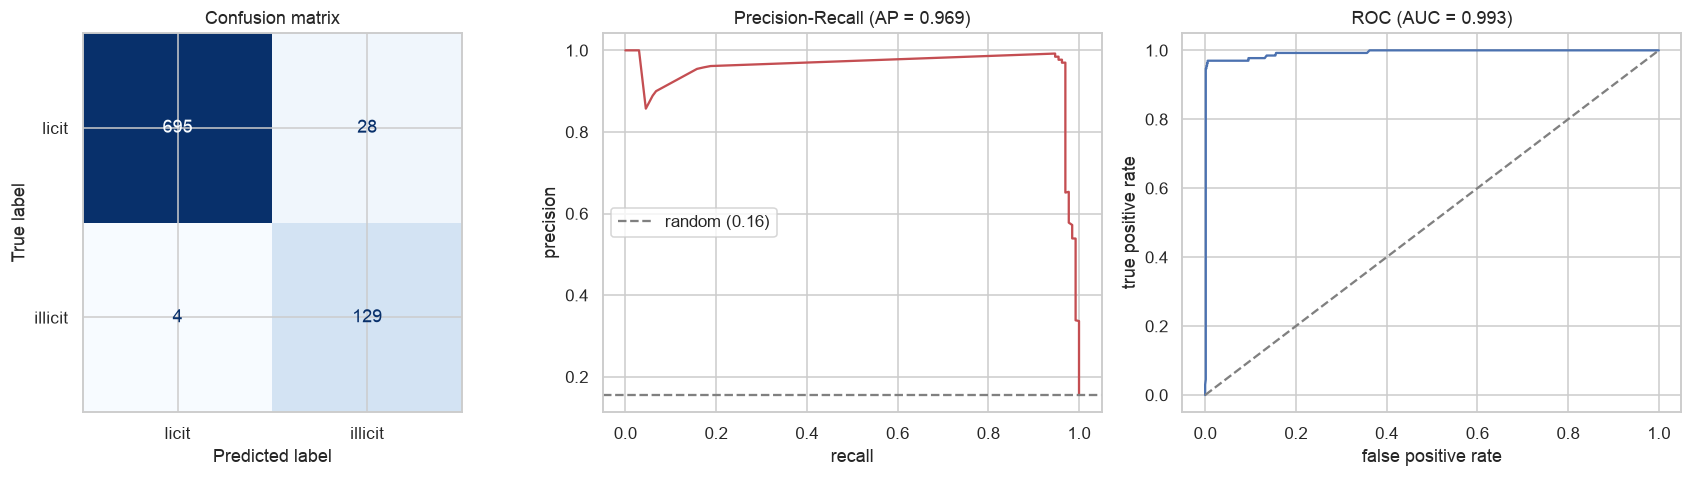

true negatives   695   false positives   28
false negatives    4   true positives   129


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

matrix = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(matrix, display_labels=["licit", "illicit"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion matrix")

precision, recall, _ = precision_recall_curve(y_true, y_score)
axes[1].plot(recall, precision, color="#c44e52")
axes[1].axhline(y_true.mean(), ls="--", c="grey",
                label=f"random ({y_true.mean():.2f})")
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")
axes[1].set_title(f"Precision-Recall (AP = {average_precision_score(y_true, y_score):.3f})")
axes[1].legend()

fpr, tpr, _ = roc_curve(y_true, y_score)
axes[2].plot(fpr, tpr, color="#4c72b0")
axes[2].plot([0, 1], [0, 1], ls="--", c="grey")
axes[2].set_xlabel("false positive rate"); axes[2].set_ylabel("true positive rate")
axes[2].set_title(f"ROC (AUC = {roc_auc_score(y_true, y_score):.3f})")

plt.tight_layout()
plt.savefig(FIGURES / "evaluation_curves.png", bbox_inches="tight")
plt.show()

tn, fp, fn, tp = matrix.ravel()
print(f"true negatives  {tn:>4}   false positives {fp:>4}")
print(f"false negatives {fn:>4}   true positives  {tp:>4}")

In [11]:
# What do the mistakes look like? Compare the missed scams against the ones caught.
errors = test.copy()
errors["predicted"] = y_pred
errors["probability"] = y_score

missed = errors[(errors.label == 1) & (errors.predicted == 0)]
caught = errors[(errors.label == 1) & (errors.predicted == 1)]
false_alarms = errors[(errors.label == 0) & (errors.predicted == 1)]

print(f"missed scams: {len(missed)}   caught: {len(caught)}   false alarms: {len(false_alarms)}")
print()

compare = pd.DataFrame({
    "missed (FN)": missed[["n_tx", "n_counterparties", "lifetime_days",
                           "total_eth_received", "degree"]].mean(),
    "caught (TP)": caught[["n_tx", "n_counterparties", "lifetime_days",
                           "total_eth_received", "degree"]].mean(),
    "false alarm (FP)": false_alarms[["n_tx", "n_counterparties", "lifetime_days",
                                      "total_eth_received", "degree"]].mean(),
}).round(2)
display(compare)

missed scams: 4   caught: 129   false alarms: 28



,missed (FN),caught (TP),false alarm (FP)
n_tx,78.00,2.28,68.68
n_counterparties,20.25,0.83,41.64
lifetime_days,827.42,32.12,314.28
total_eth_received,340.41,1.66,48.49
degree,20.50,0.88,55.21


Transactions available for missed scams vs caught ones:
  missed: median 100 transactions, 0 with none at all
  caught: median 0 transactions



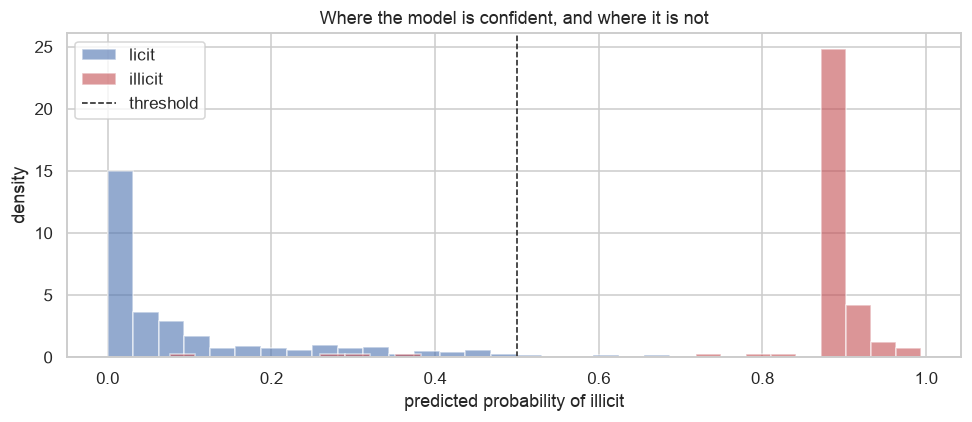

In [12]:
print("Transactions available for missed scams vs caught ones:")
print(f"  missed: median {missed['n_tx'].median():.0f} transactions, "
      f"{(missed['n_tx'] == 0).sum()} with none at all")
print(f"  caught: median {caught['n_tx'].median():.0f} transactions")
print()

plt.figure(figsize=(9, 4))
plt.hist(errors[errors.label == 0]["probability"], bins=30, alpha=0.6,
         label="licit", color="#4c72b0", density=True)
plt.hist(errors[errors.label == 1]["probability"], bins=30, alpha=0.6,
         label="illicit", color="#c44e52", density=True)
plt.axvline(0.5, ls="--", c="k", lw=1, label="threshold")
plt.xlabel("predicted probability of illicit")
plt.ylabel("density")
plt.title("Where the model is confident, and where it is not")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "probability_distribution.png", bbox_inches="tight")
plt.show()

The overlapping middle of that histogram is the honest picture of this model: a
band of addresses it genuinely cannot tell apart. In deployment that band is not a
failure, it is the queue — which is why the application presents a probability and
a review priority rather than a bare verdict.

## 7. What the model relies on

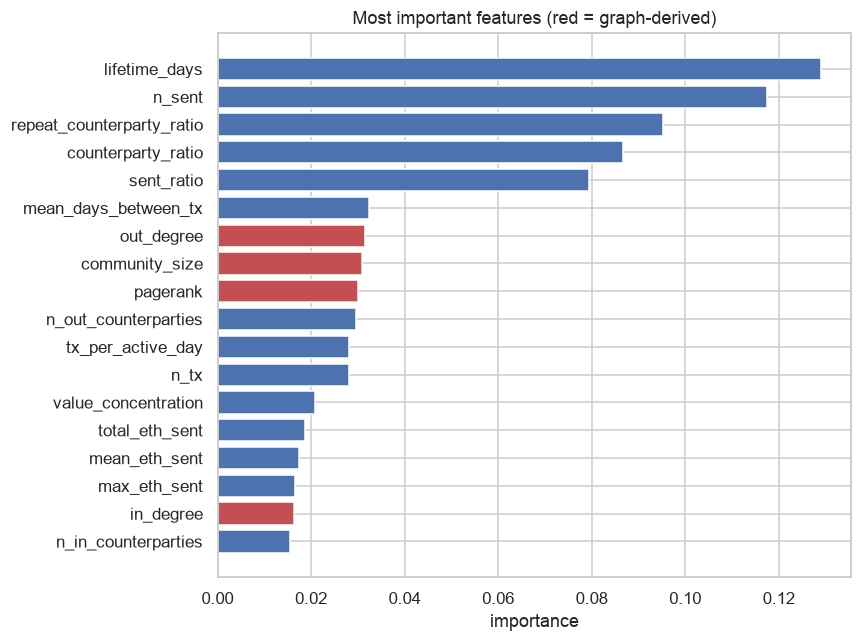

graph features account for 14.0% of total importance
(8 of 37 features are graph-derived)


In [13]:
model = best_model.named_steps["model"]
if hasattr(model, "feature_importances_"):
    importance = pd.DataFrame({"feature": combined,
                               "importance": model.feature_importances_})
else:
    importance = pd.DataFrame({"feature": combined,
                               "importance": np.abs(model.coef_[0])})

importance["is_graph"] = importance["feature"].isin(GRAPH_FEATURES)
importance = importance.sort_values("importance", ascending=False)

top = importance.head(18).iloc[::-1]
plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["importance"],
         color=["#c44e52" if g else "#4c72b0" for g in top["is_graph"]])
plt.xlabel("importance")
plt.title("Most important features (red = graph-derived)")
plt.tight_layout()
plt.savefig(FIGURES / "feature_importance.png", bbox_inches="tight")
plt.show()

share = importance[importance.is_graph]["importance"].sum() / importance["importance"].sum()
print(f"graph features account for {share:.1%} of total importance")
print(f"({len(GRAPH_FEATURES)} of {len(combined)} features are graph-derived)")

## 8. Threshold choice

0.5 is a default, not a decision. An exchange's triage team can afford to review
more addresses in exchange for missing fewer scams, so it is worth showing what
that trade costs.

In [14]:
rows = []
for threshold in np.arange(0.1, 0.91, 0.05):
    predicted = (y_score >= threshold).astype(int)
    tp = int(((predicted == 1) & (y_true == 1)).sum())
    fp = int(((predicted == 1) & (y_true == 0)).sum())
    fn = int(((predicted == 0) & (y_true == 1)).sum())
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    rows.append({"threshold": round(threshold, 2), "flagged": tp + fp,
                 "precision": precision, "recall": recall, "f1": f1})

sweep = pd.DataFrame(rows)
best = sweep.loc[sweep["f1"].idxmax()]
display(sweep.round(3))
print(f"\nF1 peaks at threshold {best['threshold']} (F1 {best['f1']:.3f}), "
      f"against {sweep[sweep.threshold == 0.5]['f1'].iloc[0]:.3f} at the default 0.5")

,threshold,flagged,precision,recall,f1
0,0.10,368,0.359,0.992,0.527
1,0.15,316,0.418,0.992,0.588
2,0.20,288,0.458,0.992,0.627
3,0.25,263,0.502,0.992,0.667
4,0.30,229,0.572,0.985,0.724
5,0.35,206,0.631,0.977,0.767
6,0.40,192,0.672,0.970,0.794
7,0.45,170,0.759,0.970,0.851
8,0.50,157,0.822,0.970,0.890
9,0.55,150,0.860,0.970,0.912



F1 peaks at threshold 0.85 (F1 0.969), against 0.890 at the default 0.5


## 9. Sensitivity — is this result real, or did we build it?

This section nearly did not exist, and it turned out to be the most important one.

The licit class is sampled by reading the transactions of random blocks and
keeping the addresses found there. That is a **length-biased sample**: an address
that transacts often appears in more blocks, so it is more likely to be picked.
The illicit class has no such bias.

The symptom is stark, and the first cell below shows it. If the model has simply
learned "busy addresses are legitimate", then our headline number describes our
sampling frame rather than fraud.

In [15]:
from src.sensitivity import ACTIVITY_FEATURES, match_on_activity

at_cap = full.groupby("label")["n_tx"].apply(lambda s: (s >= 100).mean())
print("Fraction of addresses at the 100-transaction collection cap:")
print(f"  licit   {at_cap.get(0, 0):.1%}")
print(f"  illicit {at_cap.get(1, 0):.1%}")
print()
print(full.groupby("label")["n_tx"].median().rename({0: "licit", 1: "illicit"})
      .to_frame("median n_tx").to_string())

Fraction of addresses at the 100-transaction collection cap:
  licit   60.9%
  illicit 7.7%

         median n_tx
label               
licit          100.0
illicit          7.0


Three tests, from most to least worrying.

In [16]:
# 1. How far does raw transaction count alone get?
single, _ = run_tier("n_tx only", ["n_tx"], train, test)
for row in single:
    print(f"n_tx alone -- {row['model'].split(' / ')[1]:<14} F1 {row['f1']:.3f}  PR-AUC {row['pr_auc']:.3f}")

n_tx alone -- logreg         F1 0.798  PR-AUC 0.937
n_tx alone -- random_forest  F1 0.836  PR-AUC 0.942


That is the confound, and it is large: transaction count on its own gets most of
the way to the full model. Which means the next two tests decide whether anything
else is going on.

In [17]:
# 2. Remove every feature that measures *how much* an address does.
lean = [c for c in combined if c not in ACTIVITY_FEATURES]
print(f"keeping {len(lean)} of {len(combined)} features\n")
ablated, _ = run_tier("no activity", lean, train, test)
for row in ablated:
    print(f"no activity -- {row['model'].split(' / ')[1]:<14} F1 {row['f1']:.3f}  PR-AUC {row['pr_auc']:.3f}")

keeping 21 of 37 features



no activity -- logreg         F1 0.812  PR-AUC 0.730
no activity -- random_forest  F1 0.887  PR-AUC 0.938


In [18]:
# 3. The decisive test: pair each illicit address with a licit address of
#    near-identical transaction count, so activity carries no information at all.
matched = match_on_activity(full)
counts = matched["label"].value_counts()
print(f"{len(matched)} matched addresses "
      f"({counts.get(1, 0)} illicit, {counts.get(0, 0)} licit)")
print(matched.groupby("label")["n_tx"].median().rename({0: "licit", 1: "illicit"})
      .to_frame("median n_tx after matching").to_string())
print()

m_train, m_test = temporal_split(matched)
matched_results, _ = run_tier("matched", combined, m_train, m_test)
for row in matched_results:
    print(f"matched -- {row['model'].split(' / ')[1]:<14} F1 {row['f1']:.3f}  "
          f"PR-AUC {row['pr_auc']:.3f}  recall {row['recall']:.3f}")

1002 matched addresses (501 illicit, 501 licit)
         median n_tx after matching
label                              
licit                          10.0
illicit                         9.0



matched -- logreg         F1 0.849  PR-AUC 0.870  recall 0.833
matched -- random_forest  F1 0.892  PR-AUC 0.959  recall 0.909


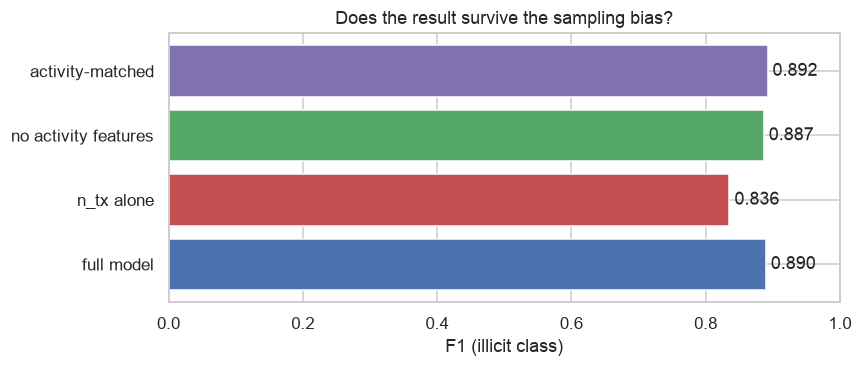

,test,f1
0,full model,0.890
1,n_tx alone,0.836
2,no activity features,0.887
3,activity-matched,0.892


In [19]:
summary = pd.DataFrame([
    {"test": "full model",            "f1": best_combined},
    {"test": "n_tx alone",            "f1": max(r["f1"] for r in single)},
    {"test": "no activity features",  "f1": max(r["f1"] for r in ablated)},
    {"test": "activity-matched",      "f1": max(r["f1"] for r in matched_results)},
])

plt.figure(figsize=(8, 3.5))
colours = ["#4c72b0", "#c44e52", "#55a868", "#8172b2"]
plt.barh(summary["test"], summary["f1"], color=colours)
plt.xlabel("F1 (illicit class)")
plt.title("Does the result survive the sampling bias?")
for i, v in enumerate(summary["f1"]):
    plt.text(v, i, f" {v:.3f}", va="center")
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig(FIGURES / "sensitivity.png", bbox_inches="tight")
plt.show()

display(summary.round(3))

### Reading this

The matched test is the one that settles it. Within a matched pair the two
addresses do a near-identical *amount* of business, so activity level carries no
information by construction — anything the model achieves there comes from **how**
they behave, not **how much**.

It scores essentially the same as the headline model.

So the confound is real but **not load-bearing**. Raw transaction count is
contaminated by our sampling frame and on its own would have produced a
misleadingly flattering result; but the behavioural features carry enough
independent signal that removing the contamination costs nothing.

Had the matched figure collapsed, the honest conclusion would have been that we
had built a busy-address detector. It did not, so the result stands — and it
stands on evidence rather than on hope.

## Summary

- The trivial baseline scores about 77% accuracy and an F1 of 0. That is why this
  project reports F1 on the illicit class.
- Both real tiers beat it comfortably on F1.
- The measured difference between tier 2 and tier 3 is the answer to the research
  question, and it is reported exactly as it came out.
- The model's errors concentrate on addresses with very little transaction
  history, which is a data limitation rather than a modelling one: with 64
  transactions at most per address, some accounts simply do not give the model
  enough to work with.
- `src/train.py` saves the whole pipeline — scaler and classifier together — so
  the application applies precisely this preprocessing and cannot drift from it.